In [1]:
import pandas as pd
import numpy as np

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
df = pd.read_csv("../data/processed/cleaned_skill_builder.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

Dataset Loaded Successfully!
Shape: (525534, 26)


In [3]:
df.head()

,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,first_action,opportunity
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,...,1.0,Box and Whisker,22763,73,0,3,32454,30799,0,1
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,...,1.0,Box and Whisker,22763,73,0,3,4922,30799,0,2
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,1.0,Box and Whisker,22763,73,0,3,42000,30799,0,1
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,...,1.0,Box and Whisker,22763,73,0,3,4859,30059,0,2
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,1.0,Box and Whisker,22763,73,3,4,124564,30060,0,3


In [4]:
feature_df = df[
    [
        "user_id",
        "skill_name",
        "correct",
        "attempt_count",
        "hint_count",
        "ms_first_response",
        "opportunity"
    ]
]

feature_df.head()

,user_id,skill_name,correct,attempt_count,hint_count,ms_first_response,opportunity
0,64525,Box and Whisker,1,1,0,32454,1
1,64525,Box and Whisker,1,1,0,4922,2
2,70363,Box and Whisker,0,2,0,25390,1
3,70363,Box and Whisker,1,1,0,4859,2
4,70363,Box and Whisker,0,14,3,19813,3


In [5]:
student_skill = (
    feature_df
    .groupby(["user_id", "skill_name"])
    .agg(
        Accuracy=("correct", "mean"),
        Avg_Attempts=("attempt_count", "mean"),
        Avg_Hints=("hint_count", "mean"),
        Avg_Response_Time=("ms_first_response", "mean"),
        Questions_Attempted=("correct", "count"),
        Max_Opportunity=("opportunity", "max")
    )
    .reset_index()
)

student_skill.head()

,user_id,skill_name,Accuracy,Avg_Attempts,Avg_Hints,Avg_Response_Time,Questions_Attempted,Max_Opportunity
0,14,Circle Graph,0.250000,0.75,1.083333,32656.750000,12,12
1,14,Equivalent Fractions,0.333333,0.50,0.500000,47747.333333,6,6
2,14,Finding Percents,0.000000,0.50,1.500000,24554.500000,2,2
3,14,Median,0.000000,1.00,2.500000,6697.250000,4,4
4,14,Percent Of,0.166667,1.00,1.666667,17566.166667,6,6


In [6]:
print(student_skill.shape)

(41576, 8)


In [7]:
student_skill.describe()

,user_id,Accuracy,Avg_Attempts,Avg_Hints,Avg_Response_Time,Questions_Attempted,Max_Opportunity
count,41576.000000,41576.000000,41576.000000,41576.000000,4.157600e+04,41576.000000,41576.000000
mean,83216.945738,0.703744,1.812003,0.391086,5.510072e+04,12.640321,12.373172
std,7250.855812,0.319198,20.638500,0.850790,1.502944e+05,43.340580,42.767747
min,14.000000,0.000000,0.000000,0.000000,-3.769725e+05,1.000000,1.000000
25%,78944.000000,0.500000,1.000000,0.000000,1.725344e+04,2.000000,2.000000
50%,80615.000000,0.777778,1.000000,0.000000,3.232092e+04,5.000000,5.000000
75%,88011.000000,1.000000,1.428571,0.375000,5.904675e+04,12.000000,11.000000
max,96299.000000,1.000000,1912.500000,7.000000,1.405387e+07,3585.000000,3585.000000


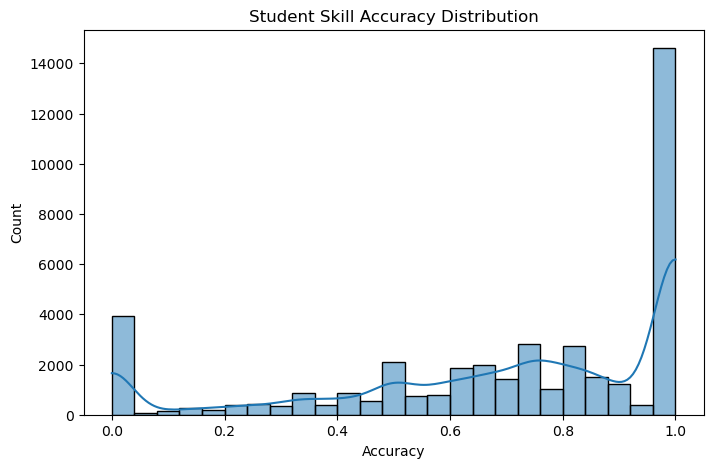

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    student_skill["Accuracy"],
    bins=25,
    kde=True
)

plt.title("Student Skill Accuracy Distribution")

plt.show()

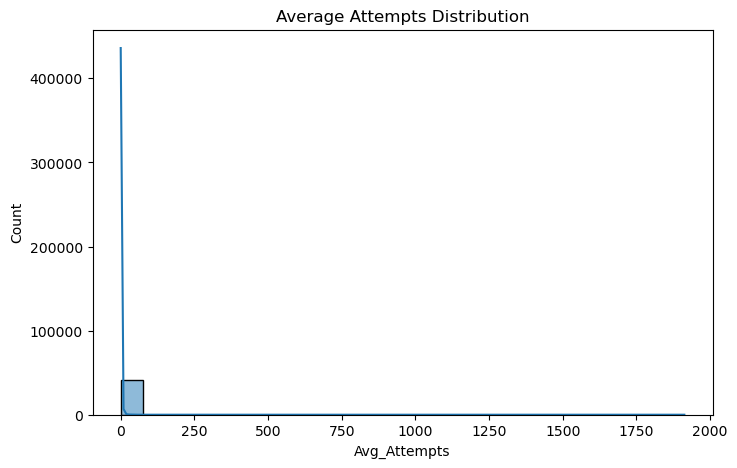

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    student_skill["Avg_Attempts"],
    bins=25,
    kde=True
)

plt.title("Average Attempts Distribution")

plt.show()

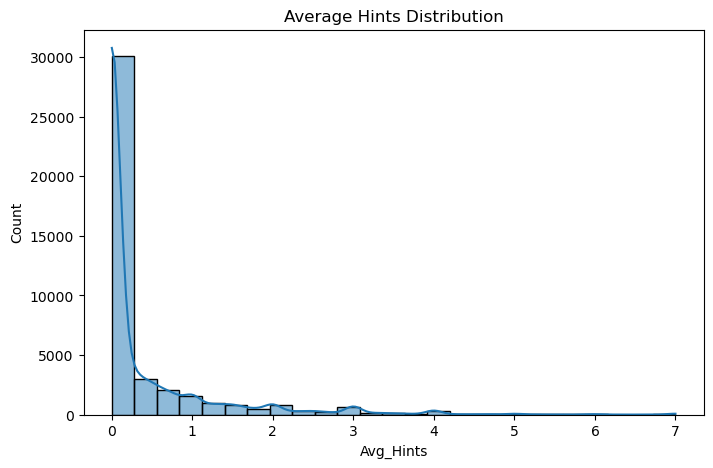

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    student_skill["Avg_Hints"],
    bins=25,
    kde=True
)

plt.title("Average Hints Distribution")

plt.show()

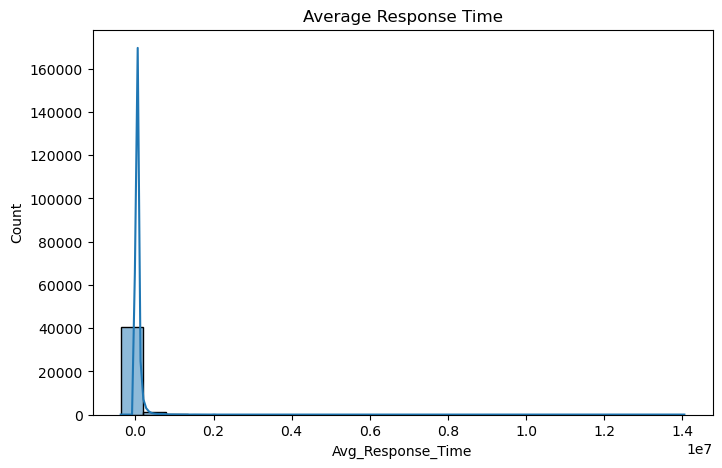

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    student_skill["Avg_Response_Time"],
    bins=25,
    kde=True
)

plt.title("Average Response Time")

plt.show()

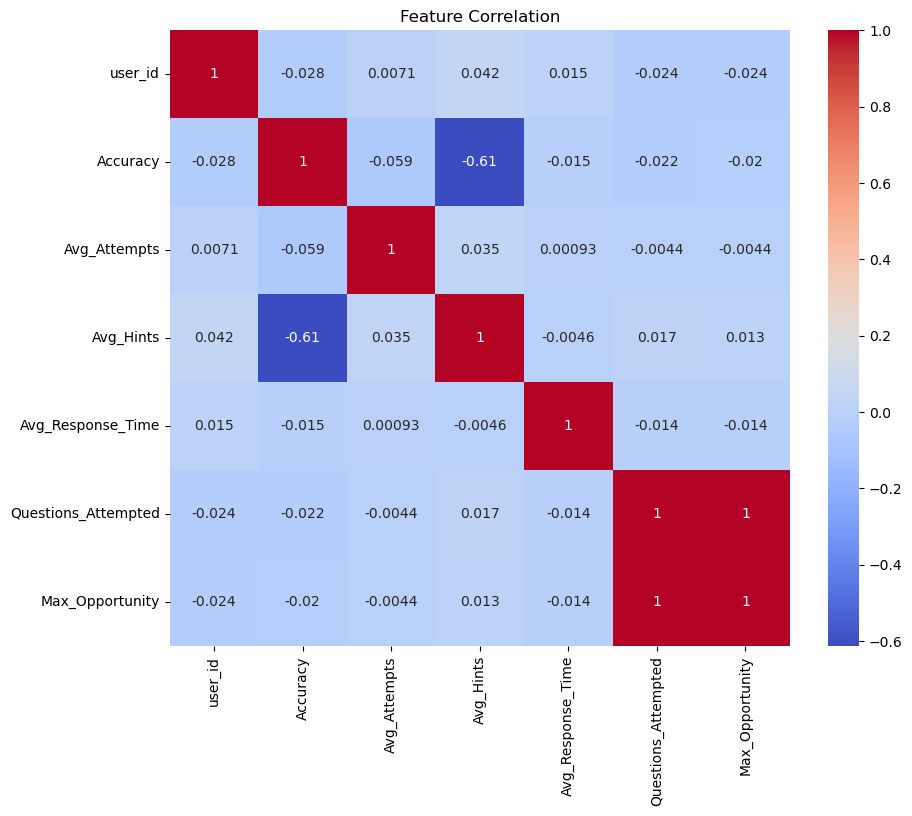

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    student_skill.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

In [13]:
student_skill.to_csv(
    "../data/processed/student_skill_features.csv",
    index=False
)

print("Feature Engineered Dataset Saved Successfully!")

Feature Engineered Dataset Saved Successfully!


In [14]:
print("="*60)
print("FEATURE ENGINEERING COMPLETED")
print("="*60)

print("Total Student-Skill Records :", len(student_skill))
print("Total Features :", student_skill.shape[1])

print("="*60)

FEATURE ENGINEERING COMPLETED
Total Student-Skill Records : 41576
Total Features : 8
